# Day 9: Business Forecasting

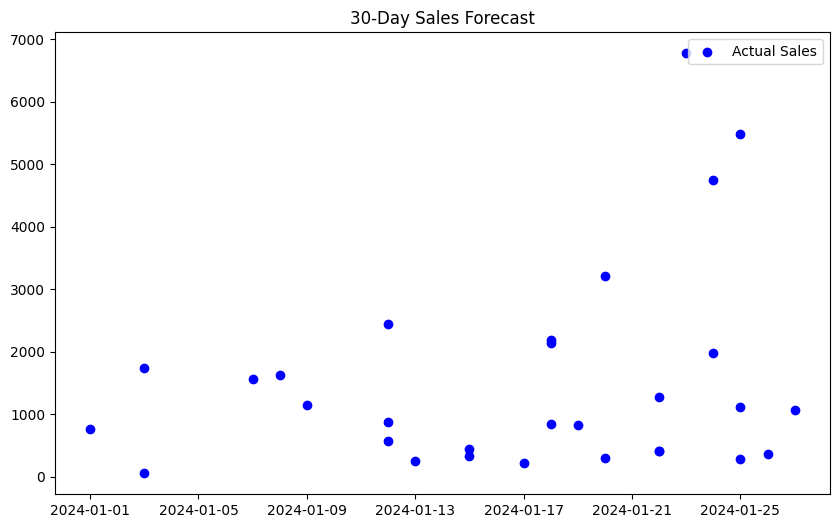

In [24]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# 1. Load your cleaned data
df = pd.read_csv("../data/sales_cleaned.csv")
df['Date'] = pd.to_datetime(df['Date'])

# 2. Convert Date to Ordinal (e.g., 738000)
df['Date_Ordinal'] = df['Date'].map(dt.datetime.toordinal)


plt.figure(figsize=(10, 6))
plt.scatter(df['Date'], df['Sales'], color='blue', label='Actual Sales')

plt.title("30-Day Sales Forecast")
plt.legend()
plt.show()

## Accuracy Check - Train on Past (first 20 days), Test on Recent (last 10 days)

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("../data/sales_cleaned copy.csv")
df['Date'] = pd.to_datetime(df['Date'])
df['Date_Ordinal'] = df['Date'].map(dt.datetime.toordinal)
df.head()

,Date,Product,Region,Quantity,Sales,Date_Ordinal
0,2024-01-01,Monitor,North,2,754.98,738886
1,2024-01-03,Monitor,East,4,1732.20,738888
2,2024-01-03,Mouse,West,1,53.61,738888
3,2024-01-07,Headphones,East,8,1566.60,738892
4,2024-01-08,Headphones,West,8,1628.57,738893


In [19]:
X = df[['Date_Ordinal']]
y = df['Sales']

model = LinearRegression()
model.fit(X_past, y_past)
print(f"Sales Trend Coefficient: {model.coef_[0]:.4f}")

Sales Trend Coefficient: 19.2034


In [20]:
last_date = df['Date_Ordinal'].max()
future_dates = np.array(range(last_date + 1, last_date + 31)).reshape(-1, 1)

# Predict!
future_preds = model.predict(future_dates)
print("Projected Sales for the first 5 days of month:")
print(future_preds[:5])

Projected Sales for the first 5 days of month:
[1291.38747222 1310.59088642 1329.79430062 1348.99771483 1368.20112903]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


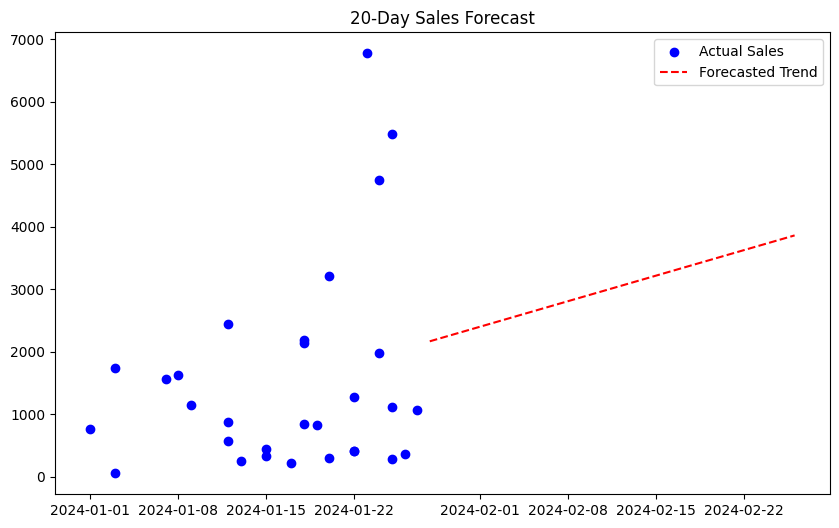

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Date'], df['Sales'], color='blue', label='Actual Sales')

# Convert future ordinals back to dates for plotting
future_dates_dt = [dt.datetime.fromordinal(int(d)) for d in future_dates.flatten()]
plt.plot(future_dates_dt, future_preds, color='red', linestyle='--', label='Forecasted Trend')

plt.title("20-Day Sales Forecast")
plt.legend()
plt.show()


## Reflection

Why might a simple Linear Forecast fail during the month of December or during a holiday sale?

A simple linear forecast draws a straight line through data and assumes sales grow or shrink at a constant rate every single day. It only captures the overall Trend. During December or holiday sales, there are sudden spikes and drops caused by Seasonality and promotional events. These patterns repeat at specific times of the year but are not constant. A linear model has no way to detect these recurring cycles. It would either underestimate sales during a holiday rush or overestimate them during a post-holiday dip. To handle this, more advanced models like Prophet or ARIMA are needed because they separate the Trend component from the Seasonal component and can account for recurring patterns in the data.